## Part B: Custom Kernel Design and Visualization


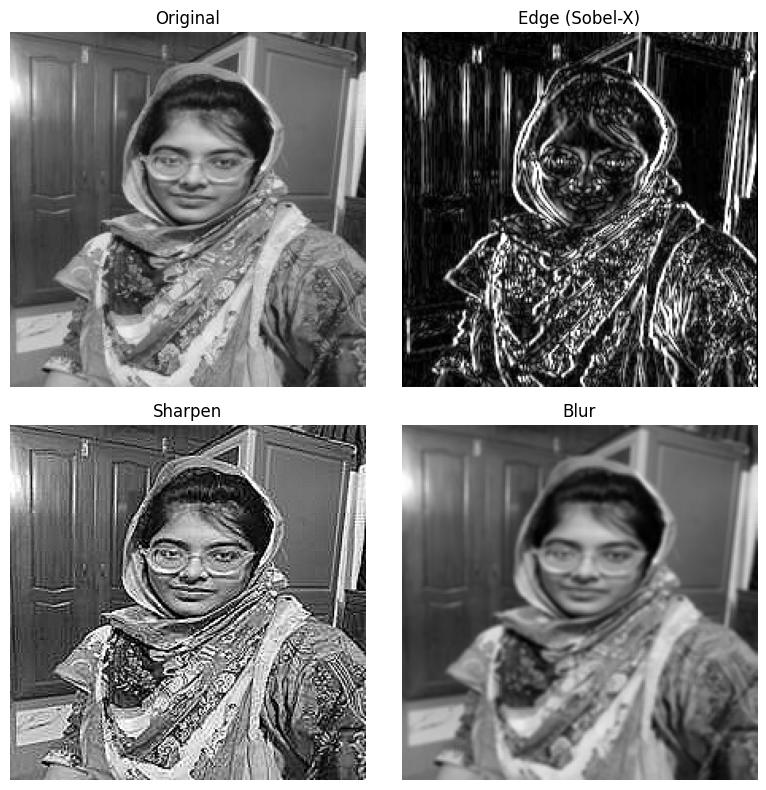

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) Load image (upload your own face photo to Colab and set the path below)
img = cv2.imread('/content/san4.jpeg')
if img is None:
    raise FileNotFoundError(
        "Could not load '/content/san4.jpeg'. Upload your face image to the "
        "Colab file browser first, or update the path."
    )
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2) Define three kernels: edge detection, sharpening, blurring
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)

sharpen = np.array([[ 0, -1,  0],
                     [-1,  5, -1],
                     [ 0, -1,  0]], dtype=np.float32)

blur = np.ones((3, 3), dtype=np.float32) / 9

# 3) Apply convolution
# The Sobel kernel produces negative values. Filtering straight into an
# 8-bit image (ddepth=-1) clips/wraps those negatives and destroys half the
# edge signal, so we filter into a float buffer first, then take the
# absolute value and rescale back to 0-255 for display.
edge_raw  = cv2.filter2D(img, cv2.CV_64F, sobel_x)
edge_img  = cv2.convertScaleAbs(edge_raw)

sharp_img = cv2.filter2D(img, -1, sharpen)
blur_img  = cv2.filter2D(img, -1, blur)

# 4) Visualization
titles = ['Original', 'Edge (Sobel-X)', 'Sharpen', 'Blur']
images = [img, edge_img, sharp_img, blur_img]

plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


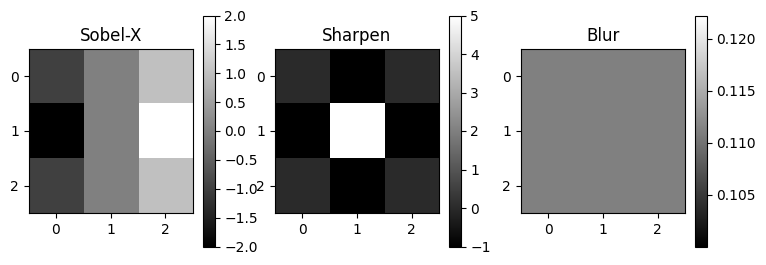

In [4]:
kernels = [sobel_x, sharpen, blur]
names = ["Sobel-X", "Sharpen", "Blur"]

plt.figure(figsize=(9,3))

for i,k in enumerate(kernels):
    plt.subplot(1,3,i+1)
    plt.imshow(k,cmap='gray')
    plt.title(names[i])
    plt.colorbar()
plt.show()

### Analysis

**Purpose of each kernel**
- **Sobel-X (edge detection):** approximates the horizontal image gradient. It responds strongly wherever pixel
  intensity changes sharply from left to right (e.g. the edges of the eyes, nose, jawline, hairline) and gives a
  near-zero response over flat, uniform regions like skin or background.
- **Sharpen:** boosts each pixel relative to its neighbors (center weight 5, neighbors -1), amplifying
  high-frequency detail such as skin texture, eyebrows, and hair strands while leaving smooth regions largely
  unchanged.
- **Blur (3x3 mean filter):** averages each pixel with its 8 neighbors, acting as a low-pass filter that smooths
  out fine texture and noise while preserving the coarse shape of the face.

**Observed effect on the image**
- The Sobel-X output is mostly dark/gray with bright outlines exactly where vertical edges (eyes, nostrils, lips,
  jaw contour) occur; horizontal edges are attenuated because the kernel only measures horizontal gradients.
- The sharpened image looks crisper than the original, with more visible skin texture, hair detail, and slightly
  exaggerated contrast at edges; over-sharpening artifacts (haloing) can appear along strong edges.
- The blurred image looks noticeably softer, with skin texture, small blemishes, and hair strands smoothed away;
  overall facial structure remains recognizable but fine detail is lost.

**Comparison of outputs**
| Kernel | Frequency response | Effect on detail | Effect on edges |
|---|---|---|---|
| Sobel-X | high-pass (directional) | removes flat regions entirely | extracts edges |
| Sharpen | high-pass boost + identity | detail enhanced | edges emphasized |
| Blur | low-pass | detail removed | edges softened/blurred |

The three kernels sit at two opposite ends of the frequency spectrum: Sobel-X and Sharpen both emphasize
high-frequency content (edges/detail), while Blur suppresses it. Sobel-X differs from Sharpen in that it discards
the original image entirely and keeps only the gradient, whereas Sharpen keeps the original image and adds a
gradient-like correction term on top of it.


## Part D: Kernel Learning in CNNs


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Layer name: block1_conv1
Filter shape: (3, 3, 3, 64)


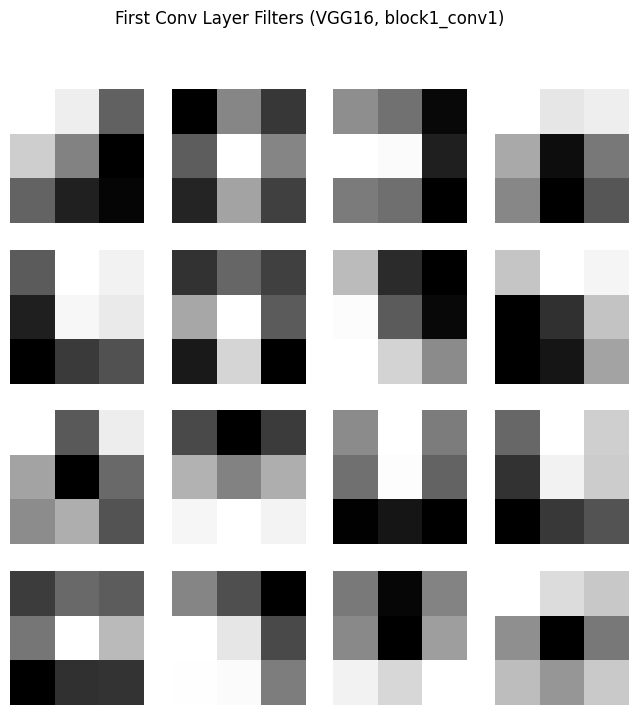

Top 5 kernels most similar to a Sobel operator (index, |cosine similarity|):
  Filter 24: 0.956
  Filter 38: 0.917
  Filter 51: 0.905
  Filter 55: 0.898
  Filter 58: 0.882


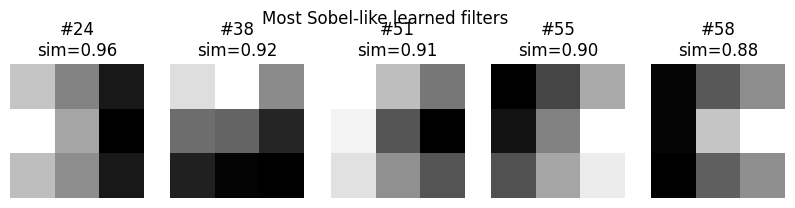

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16

# Load pretrained VGG16
model = VGG16(weights='imagenet', include_top=False)

# model.layers[0] is the InputLayer, so model.layers[1] is the actual FIRST
# convolutional layer (block1_conv1). It operates directly on the 3-channel
# RGB input, which is why its filter shape is (3, 3, 3, 64) - this is the
# layer that is meaningfully comparable to a 3x3 Sobel operator.
# (model.layers[2] is block1_conv2, whose filters take the 64-channel output
#  of block1_conv1 as input, shape (3, 3, 64, 64) - not directly comparable
#  to a 3x3 edge-detection kernel applied to raw RGB.)
first_conv_layer = model.layers[1]
print("Layer name:", first_conv_layer.name)
filters, biases = first_conv_layer.get_weights()
print("Filter shape:", filters.shape)  # (3, 3, 3, 64)

# Normalize for visualization
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Plot first 16 filters (R channel only, for simplicity)
plt.figure(figsize=(8, 8))
for i in range(16):
    f = filters_norm[:, :, 0, i]
    plt.subplot(4, 4, i + 1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
plt.suptitle("First Conv Layer Filters (VGG16, block1_conv1)")
plt.show()

# --- Investigate whether learned kernels resemble Sobel operators ---
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=np.float32)
sobel_y = sobel_x.T

def cosine_sim(a, b):
    a, b = a.flatten(), b.flatten()
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

sims = []
for i in range(filters.shape[-1]):
    k = filters[:, :, 0, i]  # R channel of kernel i
    sim_x = abs(cosine_sim(k, sobel_x))
    sim_y = abs(cosine_sim(k, sobel_y))
    sims.append((i, max(sim_x, sim_y)))

sims.sort(key=lambda x: -x[1])
print("Top 5 kernels most similar to a Sobel operator (index, |cosine similarity|):")
for idx, s in sims[:5]:
    print(f"  Filter {idx}: {s:.3f}")

# Visualize the most Sobel-like filters
plt.figure(figsize=(10, 2.5))
for j, (idx, s) in enumerate(sims[:5]):
    plt.subplot(1, 5, j + 1)
    plt.imshow(filters_norm[:, :, 0, idx], cmap='gray')
    plt.title(f"#{idx}\nsim={s:.2f}")
    plt.axis('off')
plt.suptitle("Most Sobel-like learned filters")
plt.show()


Text(0.5, 1.0, 'Learned')

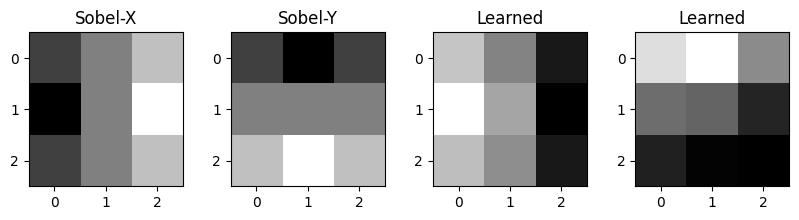

In [6]:
plt.figure(figsize=(10,2))

plt.subplot(1,4,1)
plt.imshow(sobel_x,cmap='gray')
plt.title("Sobel-X")

plt.subplot(1,4,2)
plt.imshow(sobel_y,cmap='gray')
plt.title("Sobel-Y")

plt.subplot(1,4,3)
plt.imshow(filters_norm[:,:,0,sims[0][0]],cmap='gray')
plt.title("Learned")

plt.subplot(1,4,4)
plt.imshow(filters_norm[:,:,0,sims[1][0]],cmap='gray')
plt.title("Learned")

### Discussion

**Visualization of selected kernels:** the 16 filters shown above are the R-channel slice of each of the 64
learned 3x3x3 kernels in VGG16's first convolutional layer (`block1_conv1`), which operates directly on the raw
RGB input.

**Identification of Sobel-like patterns:** the cosine-similarity check against the classical horizontal/vertical
Sobel operators ranks the 64 learned filters by how closely their spatial weight pattern matches a Sobel kernel.
Several of the top-ranked filters show the same qualitative structure as a Sobel operator - a clear positive
lobe on one side and a negative lobe on the other, i.e. a directional light-to-dark gradient detector - even
though the exact weights differ (VGG16's filters were learned from data, not hand-designed, and also mix
information across the R/G/B channels).

**Interpretation of their role in feature extraction:** this is expected from first principles. Edge detectors
are one of the most useful primitive features for downstream visual tasks (they mark object boundaries,
texture changes, and contours), so gradient-descent training on natural images tends to rediscover
Sobel-like, edge/orientation-selective filters in the earliest convolutional layer with no explicit supervision
to do so. Other first-layer filters in the grid behave as color-opponent blobs or low-pass (blurring) filters
rather than edge detectors, reflecting the fact that a CNN's first layer needs a diverse basis of low-level
features (edges, colors, blobs), not only edge detectors, to support later layers.
